# BEV Fusion Exploration (Camera + LiDAR)

In [1]:
# Core imports for data loading + plotting.
from __future__ import annotations

import json
import importlib.util
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Consistent plotting defaults make visual comparisons easier across cells.
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["image.cmap"] = "viridis"

# __file__ is not available in notebooks; discover repo root by walking up.
PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "src" / "paths.py").exists():
        PROJECT_ROOT = candidate
        break

# Load paths.py from the exact file path to avoid stale/shadowed imports.
paths_file = PROJECT_ROOT / "src" / "paths.py"
spec = importlib.util.spec_from_file_location("project_paths", paths_file)
paths = importlib.util.module_from_spec(spec)
assert spec is not None and spec.loader is not None
spec.loader.exec_module(paths)

ZOD_MOE_DATA = paths.ZOD_MOE_DATA
OUTPUTS_DIR = paths.OUTPUTS_DIR
ORIGINAL_DATA = paths.ZOD_DINO_DATA / "train2017"

print(f"Loaded paths from: {paths_file}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"ORIGINAL_DATA: {ORIGINAL_DATA}")
print(f"OUTPUTS_DIR: {OUTPUTS_DIR}")

first_frame_dir = ORIGINAL_DATA / "000000"
print(f"first_frame_dir: {first_frame_dir}")

Loaded paths from: /home/edgelab/multimodal-MoE/src/paths.py
PROJECT_ROOT: /home/edgelab/multimodal-MoE
ORIGINAL_DATA: /home/edgelab/zod_dino_data/train2017
OUTPUTS_DIR: /home/edgelab/multimodal-MoE/outputs
first_frame_dir: /home/edgelab/zod_dino_data/train2017/000000


In [2]:
#helpers
def _read_json(path: Path):
    try:
        return json.loads(path.read_text())
    except Exception as e:
        print(f"Could not read JSON: {path}\n{e}")
        return None


def _iso_to_dt(s: str) -> datetime:
    # Z-suffixed timestamp helper.
    # iso format: 2021-01-01T00:00:00.000000Z
    # datetime format: 2021-01-01 00:00:00+00:00
    return datetime.fromisoformat(s.replace("Z", "+00:00"))


def find_keyframe_timestamp(frame_dir: Path, info_dict: dict) -> datetime:
    """
    Find the keyframe timestamp from the info.json file.
    """
    return _iso_to_dt(info_dict["keyframe_time"])


def nearest_lidar_filename(frame_dir: Path) -> str | None:
    """
    Input: Keyframe Directory Path Object
    Output: LiDAR Filename (lidar_velodyne) with timestamp closest to keyframe_time
    We read the info.json file to get the keyframe_time. 
    Instead of using the full LiDAR window ~ 11-12 .npy files, we just use the closest one. 
    """
    info = _read_json(frame_dir / "info.json")
    lidar_dir = frame_dir / "lidar_velodyne"

    if not isinstance(info, dict) or "keyframe_time" not in info or not lidar_dir.exists():
        return None

    keyframe_timestamp = _iso_to_dt(info["keyframe_time"])
    best_name = None
    # initialize best absolute delta time to infinity
    best_abs_dt = float("inf")

    for p in lidar_dir.glob("*.npy"):
        # Filename pattern: <frame_id>_<car>_<ISO8601>.npy
        timestamp_str = p.stem.rsplit("_", 1)[-1]
        try:
            delta_time_s = (_iso_to_dt(timestamp_str) - keyframe_timestamp).total_seconds()
        except Exception:
            continue

        abs_dt = abs(delta_time_s)
        if abs_dt < best_abs_dt:
            best_abs_dt = abs_dt
            best_name = p.name

    return best_name

nearest_sweep_000000 = nearest_lidar_filename(first_frame_dir)
print("Nearest LiDAR filename for FRAME_DIR:", nearest_sweep_000000)

Nearest LiDAR filename for FRAME_DIR: 000000_india_2021-04-19T10:23:10.416676Z.npy


## LIDAR PROCESSING STEP 1: LiDAR --> temporally + spatially align --> .npy

In [3]:
from zod.data_classes.sensor import LidarData
from zod.data_classes.ego_motion import EgoMotion
from zod.data_classes.calibration import Calibration
#WE WILL USE THIS FUNCTION TO DENOISE THE LIDAR DATA
from zod.utils.compensation import motion_compensate_pointwise
from zod.constants import Lidar
from zod.cli import visualize_lidar
import json
from zod.data_classes.info import Information
from zod.data_classes.frame import ZodFrame
from zod.visualization.lidar_bev import BEVBox
from zod.constants import AnnotationProject, Camera, Lidar, Anonymization
from zod.data_classes.sensor import LidarData

import plotly.graph_objects as go

from zod.visualization.lidar_3d import Viz3D
from zod.visualization.lidar_on_image import (
    get_3d_transform_camera_lidar,
    project_lidar_to_image,
    draw_projection_as_jet_circles,
)
from zod.utils.geometry import transform_points, get_points_in_camera_fov

In [4]:
oxts_h5_path = first_frame_dir / "oxts.hdf5"
calib_json_path = first_frame_dir / "calibration.json"
closest_lidar_path = first_frame_dir / "lidar_velodyne" / nearest_sweep_000000

#.npy point cloud lidar nearest sweep --> LidarData object 
lidar = LidarData.from_npy(closest_lidar_path)                 # uses lidar filename for core time
# oxts.hdf5 file --> goMotion object
ego = EgoMotion.from_oxts_path(oxts_h5_path)           # gives you poses(t)
# calibration.json --> LidarCalibration object
calib = Calibration.from_json_path(calib_json_path).lidars[Lidar.VELODYNE]

In [5]:
def make_zodframe_from_raw(frame_dir: Path) -> ZodFrame:
    """
    Helper to build ZodFrame object from raw folder.
    We need this since we don't have the traditional ZOD SDK structure,
    But still want to use various methods in the ZOD SDK.
    
    INPUTS: info.json, frame_id
    OUTPUT: ZodFrame object
    """
    info_dict = json.loads((frame_dir / "info.json").read_text())
    frame_id = info_dict.get("id", frame_dir.name)
    prefix = f"single_frames/{frame_id}/"

    def fix_path(p):
        if p is None:
            return None
        if p.startswith(prefix):
            return p[len(prefix):]
        if p.startswith("single_frames/"):
            # fallback if id differs in the string
            return p.split("/", 2)[-1]
        return p

    # top-level file paths
    for k in ["calibration_path", "ego_motion_path", "metadata_path", "oxts_path", "vehicle_data_path"]:
        if info_dict.get(k) is not None:
            info_dict[k] = fix_path(info_dict[k])

    # annotation file paths
    for ann in info_dict.get("annotations", {}).values():
        if ann.get("filepath") is not None:
            ann["filepath"] = fix_path(ann["filepath"])

    # camera frame file paths
    for arr in info_dict.get("camera_frames", {}).values():
        for x in arr:
            if x.get("filepath") is not None:
                x["filepath"] = fix_path(x["filepath"])

    # lidar frame file paths
    for arr in info_dict.get("lidar_frames", {}).values():
        for x in arr:
            if x.get("filepath") is not None:
                x["filepath"] = fix_path(x["filepath"])

    info = Information.from_dict(info_dict)
    info.convert_paths_to_absolute(str(frame_dir))
    return ZodFrame(info)

In [6]:
# Compatibility shim for SDK code that still uses np.cast[...]
if not hasattr(np, "cast"):
    class _CastShim:
        def __getitem__(self, dtype):
            return lambda arr: np.asarray(arr, dtype=dtype)
    np.cast = _CastShim()

In [7]:
# Build ZOD frame object from raw folder helper
frame_dir = ORIGINAL_DATA / "000000"
zod_frame = make_zodframe_from_raw(frame_dir)

# Select nearest lidar sweep and load as SDK LidarData object
nearest_name = nearest_lidar_filename(frame_dir)

lidar_data = LidarData.from_npy(frame_dir / "lidar_velodyne" / nearest_name)

# Reuse previously extracted nearest-sweep LiDAR as the raw input for alignment.
raw_lidar = lidar_data

# Reuse SDK objects directly from zod_frame.
ego_motion = zod_frame.ego_motion
calib = zod_frame.calibration

# Front camera keyframe + exact timestamp (defaults to FRONT + BLUR in SDK).
front_camera_frame = zod_frame.get_camera_frame()
front_image = zod_frame.get_image()
camera_timestamp = front_camera_frame.time.timestamp()  # epoch seconds

print(f"Frame id: {zod_frame.info.id}")
print(f"Front image shape: {front_image.shape}")
print(f"Front camera timestamp (epoch sec): {camera_timestamp:.6f}")
print(f"Raw LiDAR points (reused nearest sweep): {raw_lidar.points.shape[0]}")

Frame id: 000000
Front image shape: (2168, 3848, 3)
Front camera timestamp (epoch sec): 1618827790.444124
Raw LiDAR points (reused nearest sweep): 256867


In [8]:
# Temporal + spatial preprocessing for BEV-BEV fusion (ZOD)
# 1) Temporal alignment: motion-compensate LiDAR sweep to the camera timestamp (deskew).
#    IMPORTANT: motion_compensate_pointwise returns points back in the LiDAR SENSOR frame (not ego).
# 2) Spatial filtering for fusion: LiDAR -> camera, keep only points in the camera frustum
#    (positive depth + angular FOV). We compute a mask in camera frame.
# 3) Apply that same mask to:
#    (A) LiDAR-frame aligned points (for projection/debug)
#    (B) Ego-frame aligned points (recommended to cache for BEV gridding)

# --- (1) Motion compensation / temporal alignment (output in LiDAR frame) ---
lidar_calib = calib.lidars[Lidar.VELODYNE]
aligned_lidar = motion_compensate_pointwise(
    raw_lidar,
    ego_motion,
    lidar_calib,
    target_timestamp=camera_timestamp,
)

# LiDAR-frame points after deskew @ t_cam
points_lidar = aligned_lidar.points  # (N, 3)

# Also create ego-frame version (NOTE: this is the ego frame at t = camera_timestamp, what we will use for BEV later
# once we filter points to only include those in the camera frustum)
aligned_lidar_ego = aligned_lidar.copy()
aligned_lidar_ego.transform(lidar_calib.extrinsics)  # LiDAR -> ego
points_ego = aligned_lidar_ego.points  # (N, 3)

# --- (2) Compute camera-frustum mask in camera coordinates (use LiDAR->camera extrinsics) ---
# we need points in camera frame 
T_lidar_to_cam = get_3d_transform_camera_lidar(
    calib, lidar=Lidar.VELODYNE, camera=Camera.FRONT
).transform

# temporally align LiDAR points in camera coordinate frame
points_cam = transform_points(points_lidar, T_lidar_to_cam)  # (N, 3)

# In front of camera
positive_depth_mask = points_cam[:, 2] > 0
points_cam_positive = points_cam[positive_depth_mask]

# Within angular FOV
# NOTE: get_points_in_camera_fov() is independent of image resolution
_, fov_mask_positive = get_points_in_camera_fov(
    calib.cameras[Camera.FRONT].field_of_view,
    points_cam_positive,
)

# Lift back to full indexing
fov_mask_full = np.zeros(points_cam.shape[0], dtype=bool)
fov_mask_full[positive_depth_mask] = fov_mask_positive

# --- (3A) Camera-frame XYZI (optional debug for projection checks) ---
fov_points_cam = points_cam[fov_mask_full]
fov_intensity = aligned_lidar.intensity[fov_mask_full]
fov_points_cam_xyzi = np.hstack(
    [fov_points_cam.astype(np.float32), fov_intensity.astype(np.float32)[:, None]]
)

# --- (3B) Ego-frame XYZI (recommended to cache for BEV) ---
fov_points_ego = points_ego[fov_mask_full] # (K, 3)  ego-frame XYZ, deskewed to t_cam, inside camera FOV
fov_points_ego_xyzi = np.hstack(
    [fov_points_ego.astype(np.float32), fov_intensity.astype(np.float32)[:, None]]
) # (K, 4)  ego-frame XYZ + intensity, deskewed to t_cam, inside camera FOV
#FOR BEV we will use fov_points_ego_xyzi. 


# filtered LidarData objects for existing viz utilities
fov_lidar_lidarframe = aligned_lidar.copy()
fov_lidar_lidarframe.points = points_lidar[fov_mask_full]
fov_lidar_lidarframe.intensity = fov_intensity
fov_lidar_lidarframe.timestamps = aligned_lidar.timestamps[fov_mask_full]
fov_lidar_lidarframe.diode_idx = aligned_lidar.diode_idx[fov_mask_full]

fov_lidar_egoframe = aligned_lidar_ego.copy()
fov_lidar_egoframe.points = fov_points_ego
fov_lidar_egoframe.intensity = fov_intensity
fov_lidar_egoframe.timestamps = aligned_lidar_ego.timestamps[fov_mask_full]
fov_lidar_egoframe.diode_idx = aligned_lidar_ego.diode_idx[fov_mask_full]

print(f"Aligned LiDAR points (all): {points_lidar.shape[0]}")
print(f"Positive-depth points: {points_cam_positive.shape[0]}")
print(f"FOV points (camera frame): {fov_points_cam.shape[0]}")
print(f"FOV XYZI tensor (camera frame, debug): {fov_points_cam_xyzi.shape}")
print(f"FOV XYZI tensor (ego frame, cache for BEV): {fov_points_ego_xyzi.shape}")

Aligned LiDAR points (all): 256867
Positive-depth points: 120340
FOV points (camera frame): 81286
FOV XYZI tensor (camera frame, debug): (81286, 4)
FOV XYZI tensor (ego frame, cache for BEV): (81286, 4)


In [9]:
# Raw vs aligned in one plot + shift vectors (2 plots)

rng = np.random.default_rng(0)

def _sample_idx(n, max_points=120_000):
    if n <= max_points:
        return np.arange(n)
    return rng.choice(n, size=max_points, replace=False)

# ---------- Figure 1: dense point-cloud overlay ----------
raw_idx = _sample_idx(raw_lidar.points.shape[0], max_points=100_000)
aligned_idx = _sample_idx(aligned_lidar.points.shape[0], max_points=100_000)

viz_shift = Viz3D()

viz_shift.fig.add_trace(
    go.Scatter3d(
        x=raw_lidar.points[raw_idx, 0],
        y=raw_lidar.points[raw_idx, 1],
        z=raw_lidar.points[raw_idx, 2],
        mode="markers",
        name="Raw LiDAR",
        marker=dict(size=1, color="red", opacity=0.30),
    )
)

viz_shift.fig.add_trace(
    go.Scatter3d(
        x=aligned_lidar.points[aligned_idx, 0],
        y=aligned_lidar.points[aligned_idx, 1],
        z=aligned_lidar.points[aligned_idx, 2],
        mode="markers",
        name="Motion-compensated LiDAR",
        marker=dict(size=1, color="deepskyblue", opacity=0.65),
    )
)

viz_shift.fig.update_layout(
    title="Un-skewing: raw (red) vs motion-compensated (blue)",
    scene=dict(
        aspectmode="data",
        xaxis=dict(title="x (m)", range=[-200, 200]),
        yaxis=dict(title="y (m)", range=[-200, 200]),
        zaxis=dict(title="z (m)", range=[-5, 5]),
        camera=dict(
            projection=dict(type="orthographic"),
            eye=dict(x=0.0, y=0.0, z=2.8),
            up=dict(x=0.0, y=1.0, z=0.0),
        ),
    ),
    legend=dict(x=0.01, y=0.99),
)

print("####")
viz_shift.fig.show()
print("####")


# ---------- Figure 2: vectors only, differences between raw and aligned LiDAR points ----------
SHOW_VECTOR_FIG = True
if SHOW_VECTOR_FIG:
    k = min(1200, raw_lidar.points.shape[0], aligned_lidar.points.shape[0])  # small for clarity
    idx_line = rng.choice(min(raw_lidar.points.shape[0], aligned_lidar.points.shape[0]), size=k, replace=False)

    x_line = np.stack(
        [raw_lidar.points[idx_line, 0], aligned_lidar.points[idx_line, 0], np.full(k, np.nan)],
        axis=1,
    ).reshape(-1)
    y_line = np.stack(
        [raw_lidar.points[idx_line, 1], aligned_lidar.points[idx_line, 1], np.full(k, np.nan)],
        axis=1,
    ).reshape(-1)
    z_line = np.stack(
        [raw_lidar.points[idx_line, 2], aligned_lidar.points[idx_line, 2], np.full(k, np.nan)],
        axis=1,
    ).reshape(-1)

    viz_vec = Viz3D()
    viz_vec.fig.add_trace(
        go.Scatter3d(
            x=x_line,
            y=y_line,
            z=z_line,
            mode="lines",
            name="Point shift vectors",
            line=dict(color="yellow", width=4),
            opacity=0.9,
        )
    )
    viz_vec.fig.update_layout(
        title=f"Un-skewing shift vectors only (k={k})",
        scene=dict(
            aspectmode="data",
            xaxis=dict(title="x (m)", range=[-200, 200]),
            yaxis=dict(title="y (m)", range=[-200, 200]),
            zaxis=dict(title="z (m)", range=[-5, 5]),
            camera=dict(
                projection=dict(type="orthographic"),
                eye=dict(x=0.0, y=0.0, z=2.8),
                up=dict(x=0.0, y=1.0, z=0.0),
            ),
        ),
    )


viz_vec.fig.show()

####


####


In [10]:
# (top-down FOV restriction)
# Plot only LiDAR points that survive camera FOV filtering.
# This should reveal the camera frustum footprint as a V-like wedge.

fov_idx = _sample_idx(fov_lidar_egoframe.points.shape[0], max_points=120_000)

viz_fov = Viz3D()
viz_fov.fig.add_trace(
    go.Scatter3d(
        x=fov_lidar_egoframe.points[fov_idx, 0],
        y=fov_lidar_egoframe.points[fov_idx, 1],
        z=fov_lidar_egoframe.points[fov_idx, 2],
        mode="markers",
        name="FOV-filtered LiDAR",
        marker=dict(size=1, color="orange", opacity=0.75),
    )
)

viz_fov.fig.update_layout(
    title="Top-down view: camera-FOV-restricted LiDAR",
    scene=dict(
        aspectmode="data",
        xaxis=dict(title="x (m)", range=[0, 250]),
        yaxis=dict(title="y (m)", range=[-100, 100]),
        zaxis=dict(title="z (m)", range=[-5, 3]),
        camera=dict(
            projection=dict(type="orthographic"),
            eye=dict(x=0.0, y=0.0, z=2.8),
            up=dict(x=0.0, y=1.0, z=0.0),
        ),
    ),
)
#

viz_fov.fig.show()

# Optional save:
# viz_fov.fig.write_html("fov_restricted_topdown.html")


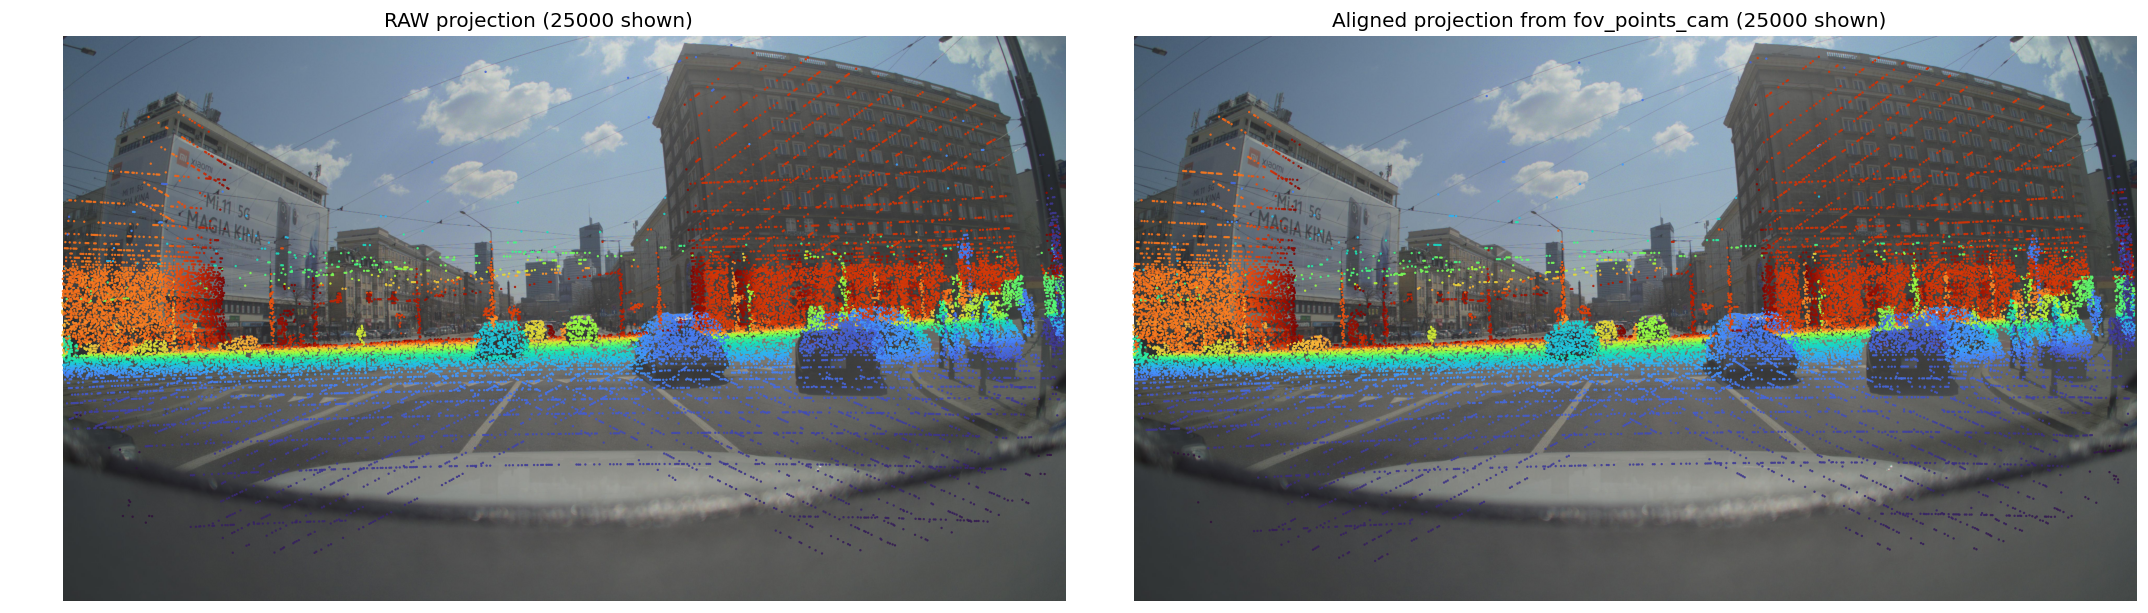

Raw projected total: 80776
Aligned projected total (from fov_points_cam): 81286


In [11]:
# using camera-frame FOV LiDAR points we created above.

from zod.utils.geometry import project_3d_to_2d_kannala

# Raw projection (left panel, unchanged reference) ---
raw_xyd, _ = project_lidar_to_image(raw_lidar, calib, lidar=Lidar.VELODYNE, camera=Camera.FRONT)

#  Aligned projection from camera-frame FOV points ---
# fov_points_cam is already positive-depth + FOV-filtered in camera frame.
xy_aligned = project_3d_to_2d_kannala(
    fov_points_cam,
    calib.cameras[Camera.FRONT].intrinsics[..., :3],
    calib.cameras[Camera.FRONT].distortion,
)
aligned_xyd = np.concatenate([xy_aligned, fov_points_cam[:, 2:3]], axis=1)  # [u,v,depth]

# --- 3) Simple display filtering (for readability only) ---
def _display_subset(xyd, max_points=25000, min_depth=1.5, max_depth=60.0, seed=0):
    keep = (xyd[:, 2] >= min_depth) & (xyd[:, 2] <= max_depth)
    pts = xyd[keep]
    if pts.shape[0] > max_points:
        rng = np.random.default_rng(seed)
        pts = pts[rng.choice(pts.shape[0], size=max_points, replace=False)]
    return pts

raw_pts = _display_subset(raw_xyd, max_points=25000, seed=0)
aln_pts = _display_subset(aligned_xyd, max_points=25000, seed=1)

# --- 4) Plot side-by-side ---
fig, axs = plt.subplots(1, 2, figsize=(18, 7), dpi=120)

for ax, pts, title in [
    (axs[0], raw_pts, f"RAW projection ({raw_pts.shape[0]} shown)"),
    (axs[1], aln_pts, f"Aligned projection from fov_points_cam ({aln_pts.shape[0]} shown)"),
]:
    ax.imshow(front_image)
    if pts.shape[0] > 0:
        ax.scatter(
            pts[:, 0], pts[:, 1],
            c=pts[:, 2],
            s=2.0,
            cmap="turbo",
            alpha=0.9,
            linewidths=0,
        )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()

plt.show()


print("Raw projected total:", raw_xyd.shape[0])
print("Aligned projected total (from fov_points_cam):", aligned_xyd.shape[0])

# Determining BEV grid size:

DATASET_ROOT: /home/edgelab/zod_dino_data/train2017
Found frame dirs: 20000


Scanning 3D ped annotations:   0%|          | 0/20000 [00:00<?, ?it/s]

[50/20000] rows=165 objs=3553 ped=219 ped_3d=165 failed_frames=0 elapsed=7.7s avg_per_frame=0.155s
[100/20000] rows=307 objs=7543 ped=409 ped_3d=307 failed_frames=0 elapsed=14.1s avg_per_frame=0.141s
[150/20000] rows=467 objs=11577 ped=614 ped_3d=467 failed_frames=0 elapsed=20.0s avg_per_frame=0.133s
[200/20000] rows=622 objs=15450 ped=843 ped_3d=622 failed_frames=0 elapsed=26.0s avg_per_frame=0.130s
[250/20000] rows=756 objs=19040 ped=1044 ped_3d=756 failed_frames=0 elapsed=31.5s avg_per_frame=0.126s
[300/20000] rows=876 objs=22134 ped=1196 ped_3d=876 failed_frames=0 elapsed=36.9s avg_per_frame=0.123s
[350/20000] rows=999 objs=25559 ped=1363 ped_3d=999 failed_frames=0 elapsed=41.9s avg_per_frame=0.120s
[400/20000] rows=1142 objs=28687 ped=1560 ped_3d=1142 failed_frames=0 elapsed=46.6s avg_per_frame=0.116s
[450/20000] rows=1262 objs=32383 ped=1713 ped_3d=1262 failed_frames=0 elapsed=51.5s avg_per_frame=0.114s
[500/20000] rows=1414 objs=35960 ped=1909 ped_3d=1414 failed_frames=0 elapsed

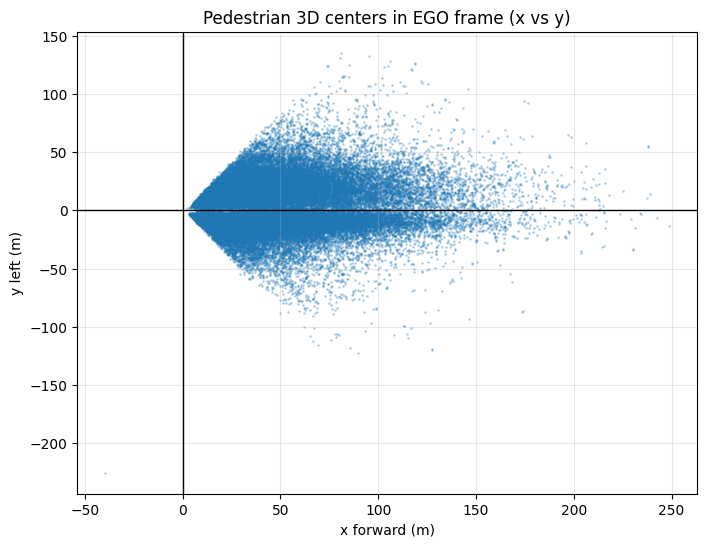

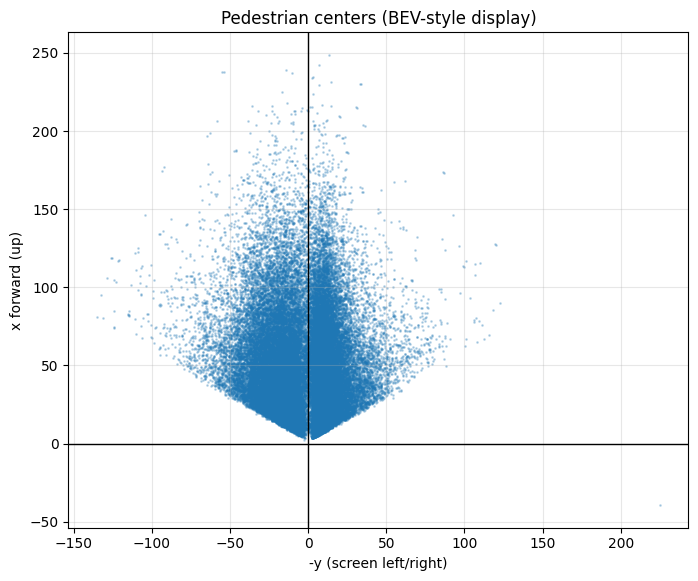


=== BEV grid sizes (robust y-bound) ===
Resolution 0.25 m -> grid 1000 x 825 (0.82M cells)
Resolution 0.50 m -> grid 500 x 412 (0.21M cells)
Resolution 1.00 m -> grid 250 x 206 (0.05M cells)


In [16]:
# ============================================================
# BEV bounds from pedestrian 3D annotations (ZOD) 
# - Converts location_3d (LiDAR frame) -> EGO before stats
# ============================================================

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

from zod.data_classes.calibration import Calibration
from zod.constants import Lidar
from zod.utils.geometry import transform_points

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
MARGIN_METERS = 2.0
X_MAX_FIXED = 250.0
MAX_FRAMES = 20000      # set None for full dataset
PRINT_EVERY = 50        # heartbeat

DATASET_ROOT = Path("/home/edgelab/zod_dino_data/train2017")
print(f"DATASET_ROOT: {DATASET_ROOT}", flush=True)

# ------------------------------------------------------------
# DISCOVER FRAMES (unsorted for speed)
# ------------------------------------------------------------
frame_dirs = [
    p for p in DATASET_ROOT.iterdir()
    if p.is_dir()
    and (p / "info.json").exists()
    and (p / "calibration.json").exists()
    and (p / "annotations" / "object_detection.json").exists()
]
if MAX_FRAMES is not None:
    frame_dirs = frame_dirs[:MAX_FRAMES]

print(f"Found frame dirs: {len(frame_dirs)}", flush=True)

# ------------------------------------------------------------
# ITERATE THROUGH DATASET
# ------------------------------------------------------------
rows = []
n_failed_frames = 0
n_total_objects = 0
n_ped_objects = 0
n_ped_with_3d = 0

# timing diagnostics
t_total_start = time.perf_counter()
t_calib_total = 0.0
t_ann_read_total = 0.0
t_ann_parse_total = 0.0
t_obj_loop_total = 0.0

pbar = tqdm(
    frame_dirs,
    desc="Scanning 3D ped annotations",
    miniters=1,
    mininterval=0.5,
    dynamic_ncols=True,
)

for i, frame_dir in enumerate(pbar, start=1):
    frame_id = frame_dir.name
    ann_path = frame_dir / "annotations" / "object_detection.json"
    calib_path = frame_dir / "calibration.json"

    frame_start = time.perf_counter()

    try:
        t0 = time.perf_counter()
        calib = Calibration.from_json_path(str(calib_path))
        T_lidar_to_ego = calib.lidars[Lidar.VELODYNE].extrinsics.transform
        t_calib_total += time.perf_counter() - t0

        t0 = time.perf_counter()
        ann_text = ann_path.read_text()
        t_ann_read_total += time.perf_counter() - t0

        t0 = time.perf_counter()
        anns = json.loads(ann_text)
        t_ann_parse_total += time.perf_counter() - t0

        if not isinstance(anns, list):
            n_failed_frames += 1
            continue

        t0 = time.perf_counter()
        for obj in anns:
            if not isinstance(obj, dict):
                continue
            props = obj.get("properties", {})
            if not isinstance(props, dict):
                continue

            n_total_objects += 1

            cls_l = str(props.get("class", "")).lower()
            typ_l = str(props.get("type", "")).lower()

            # Pedestrian filter
            if ("pedestrian" not in cls_l) and ("pedestrian" not in typ_l) and (cls_l != "person") and (typ_l != "person"):
                continue
            n_ped_objects += 1

            loc3d = props.get("location_3d")
            if not isinstance(loc3d, dict):
                continue
            coords = loc3d.get("coordinates")
            if not (isinstance(coords, (list, tuple)) and len(coords) >= 3):
                continue

            n_ped_with_3d += 1

            # location_3d is interpreted by ZOD as LiDAR frame -> convert to EGO
            pt_lidar = np.array(coords[:3], dtype=np.float32).reshape(1, 3)
            pt_ego = transform_points(pt_lidar, T_lidar_to_ego)[0]

            rows.append({
                "frame_id": frame_id,
                "x": float(pt_ego[0]),   # forward
                "y": float(pt_ego[1]),   # left/right
                "z": float(pt_ego[2]),   # up
            })
        t_obj_loop_total += time.perf_counter() - t0

    except Exception as e:
        n_failed_frames += 1
        tqdm.write(f"Failed on frame {frame_id}: {type(e).__name__}: {e}")

    frame_time = time.perf_counter() - frame_start

    pbar.set_postfix({
        "rows": len(rows),
        "ped3d": n_ped_with_3d,
        "fail": n_failed_frames,
        "sec/frame": f"{frame_time:.3f}",
    })

    if i % PRINT_EVERY == 0:
        elapsed = time.perf_counter() - t_total_start
        avg_per_frame = elapsed / i
        tqdm.write(
            f"[{i}/{len(frame_dirs)}] rows={len(rows)} "
            f"objs={n_total_objects} ped={n_ped_objects} ped_3d={n_ped_with_3d} "
            f"failed_frames={n_failed_frames} elapsed={elapsed:.1f}s "
            f"avg_per_frame={avg_per_frame:.3f}s"
        )

# final timing breakdown
elapsed_total = time.perf_counter() - t_total_start
print("\n=== Timing breakdown ===", flush=True)
print(f"Total elapsed:           {elapsed_total:.2f} s", flush=True)
print(f"Calibration load total: {t_calib_total:.2f} s", flush=True)
print(f"Annotation read total:  {t_ann_read_total:.2f} s", flush=True)
print(f"Annotation parse total: {t_ann_parse_total:.2f} s", flush=True)
print(f"Object loop total:      {t_obj_loop_total:.2f} s", flush=True)

# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------
df = pd.DataFrame(rows)

print("\n=== Scan summary ===", flush=True)
print(f"Total objects scanned:        {n_total_objects}", flush=True)
print(f"Pedestrian objects found:     {n_ped_objects}", flush=True)
print(f"Pedestrian objects with 3D:   {n_ped_with_3d}", flush=True)
print(f"Frames failed during parse:   {n_failed_frames}", flush=True)
print(f"Total pedestrian 3D rows:     {len(df)}", flush=True)

if df.empty:
    raise RuntimeError("No pedestrian 3D annotations collected.")

# ------------------------------------------------------------
# COMPUTE DISTRIBUTION STATISTICS
# ------------------------------------------------------------
abs_y = np.abs(df["y"].to_numpy())

stats = {
    "x_min": float(df["x"].min()),
    "x_max": float(df["x"].max()),
    "x_p99": float(np.percentile(df["x"], 99)),
    "x_p999": float(np.percentile(df["x"], 99.9)),
    "y_min": float(df["y"].min()),
    "y_max": float(df["y"].max()),
    "abs_y_max": float(abs_y.max()),
    "abs_y_p99": float(np.percentile(abs_y, 99)),
    "abs_y_p999": float(np.percentile(abs_y, 99.9)),
    "abs_y_p9995": float(np.percentile(abs_y, 99.95)),
}

print("\n=== Pedestrian center statistics (EGO frame) ===", flush=True)
for k, v in stats.items():
    print(f"{k:15s}: {v:9.3f}", flush=True)

# ------------------------------------------------------------
# RECOMMENDED BEV BOUNDS
# ------------------------------------------------------------
y_bound_strict = stats["abs_y_max"] + MARGIN_METERS
y_bound_robust = stats["abs_y_p999"] + MARGIN_METERS

print("\n=== Suggested BEV bounds ===", flush=True)
print("\nStrict bounds (include everything):", flush=True)
print(f"x: [0, {X_MAX_FIXED}]", flush=True)
print(f"y: [-{y_bound_strict:.1f}, {y_bound_strict:.1f}]", flush=True)

print("\nRobust bounds (99.9% coverage):", flush=True)
print(f"x: [0, {X_MAX_FIXED}]", flush=True)
print(f"y: [-{y_bound_robust:.1f}, {y_bound_robust:.1f}]", flush=True)

# ------------------------------------------------------------
# VISUALIZE DISTRIBUTION
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(df["x"], df["y"], s=1, alpha=0.25)
plt.xlabel("x forward (m)")
plt.ylabel("y left (m)")
plt.title("Pedestrian 3D centers in EGO frame (x vs y)")
plt.axvline(0, color="black", linewidth=1)
plt.axhline(0, color="black", linewidth=1)
plt.grid(True, alpha=0.3)
plt.show()

# BEV-style plot: forward up
plt.figure(figsize=(8, 8))
plt.scatter(-df["y"], df["x"], s=1, alpha=0.25)
plt.xlabel("-y (screen left/right)")
plt.ylabel("x forward (up)")
plt.title("Pedestrian centers (BEV-style display)")
plt.axvline(0, color="black", linewidth=1)
plt.axhline(0, color="black", linewidth=1)
plt.gca().set_aspect("equal", "box")
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# BEV GRID SIZE ESTIMATE
# ------------------------------------------------------------
def grid_size(x_range, y_range, resolution):
    x_cells = int((x_range[1] - x_range[0]) / resolution)
    y_cells = int((y_range[1] - y_range[0]) / resolution)
    return x_cells, y_cells, x_cells * y_cells

print("\n=== BEV grid sizes (robust y-bound) ===", flush=True)
for res in [0.25, 0.5, 1.0]:
    gx, gy, cells = grid_size((0, X_MAX_FIXED), (-y_bound_robust, y_bound_robust), res)
    print(f"Resolution {res:.2f} m -> grid {gx} x {gy} ({cells/1e6:.2f}M cells)", flush=True)

### SAVE OUTPUTS TO USE FOR BEVFUSION:


In [15]:
out = Path("/home/edgelab/multimodal-MoE/outputs/tmp")
out.mkdir(parents=True, exist_ok=True)

# save your already prepared point cloud
np.save(out / "fov_points_cam_xyzi.npy", fov_points_cam_xyzi.astype(np.float32))
print("saved:", out / "fov_points_cam_xyzi.npy", fov_points_cam_xyzi.shape)

saved: /home/edgelab/multimodal-MoE/outputs/tmp/fov_points_cam_xyzi.npy (81286, 4)
